# **IMPORTING REQUIRED LIBRARIES**

In [1]:
# IMPORTING LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report


# **DATASET LOADING**

In [2]:
# LOADING THE DATASET
df = pd.read_csv('room_occupancy_detection_data.csv')

# Previewing dataset
print("Dataset Preview:\n")
print(df.head())

print("\nColumns:\n", df.columns)

Dataset Preview:

         datetime  indoor_co2_concentration  indoor_operative_temperature  \
0  30-01-23 00:00                     637.1                          20.4   
1  30-01-23 00:15                     637.6                          20.4   
2  30-01-23 00:30                     629.0                          20.4   
3  30-01-23 00:45                     790.2                          20.5   
4  30-01-23 01:00                     861.7                          20.6   

   indoor_relative_humidity  current_value_minus_average_last_hour_co2  \
0                      37.5                                       0.00   
1                      37.6                                       0.00   
2                      37.6                                       0.00   
3                      39.1                                       0.00   
4                      39.7                                     188.23   

   current_value_minus_average_last_hour_operative_temperature  \
0       

# **DATA PREPROCESSING**

In [7]:
# PREPROCESSING

# Droping datetime column as it's not a numerical feature
if 'datetime' in df.columns:
    df = df.drop(['datetime'], axis=1)

# Droping date
if 'date' in df.columns:
    df = df.drop(['date'], axis=1)

# Defining features and target
X = df.drop('occupancy_ground_truth', axis=1)
y = df['occupancy_ground_truth']

# **EDA Plots**

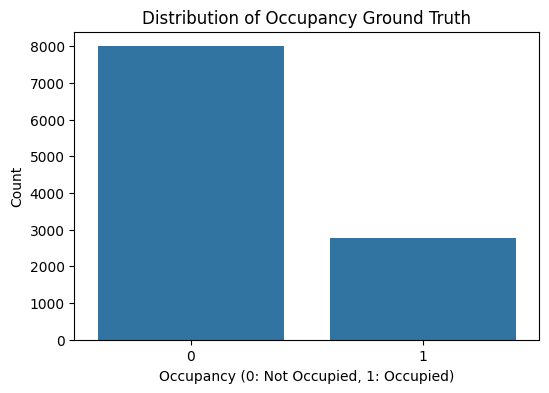

In [17]:
# Distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title('Distribution of Occupancy Ground Truth')
plt.xlabel('Occupancy (0: Not Occupied, 1: Occupied)')
plt.ylabel('Count')
plt.show()

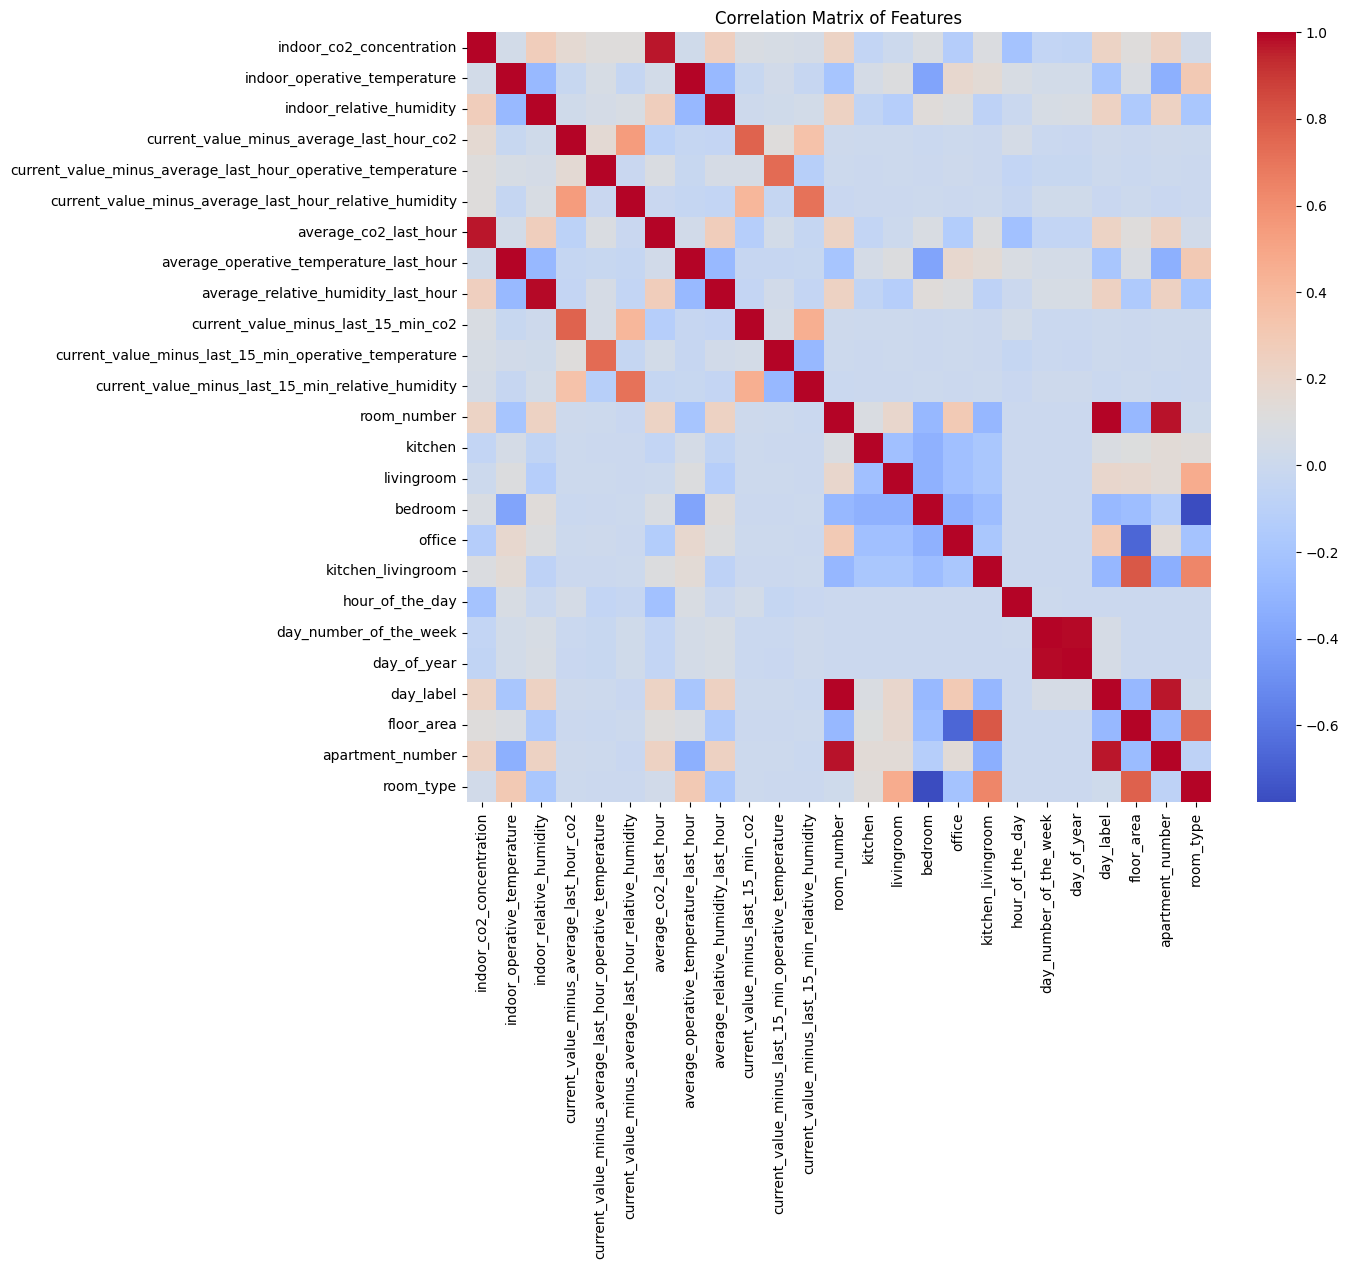

In [18]:
# Correlation Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(X.corr(), annot=False, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

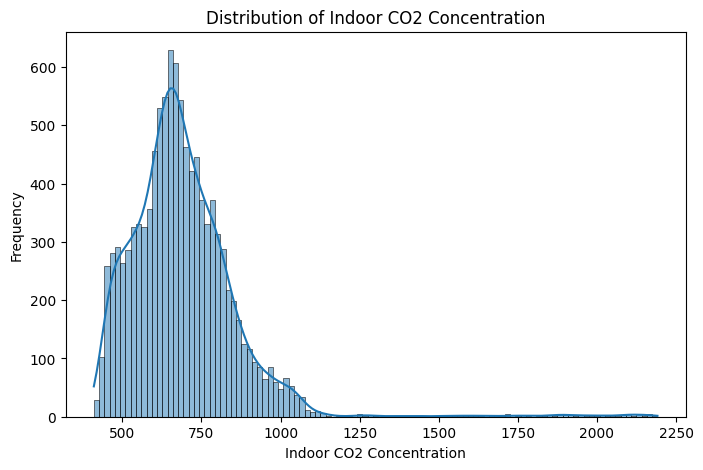

In [19]:
# Distribution of indoor_co2_concentration
plt.figure(figsize=(8, 5))
sns.histplot(df['indoor_co2_concentration'], kde=True)
plt.title('Distribution of Indoor CO2 Concentration')
plt.xlabel('Indoor CO2 Concentration')
plt.ylabel('Frequency')
plt.show()

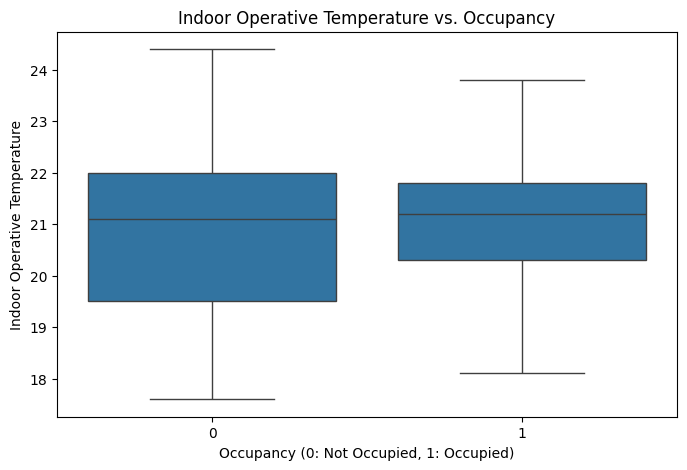

In [20]:
# Box plot of indoor_operative_temperature vs. Occupancy
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['occupancy_ground_truth'], y=df['indoor_operative_temperature'])
plt.title('Indoor Operative Temperature vs. Occupancy')
plt.xlabel('Occupancy (0: Not Occupied, 1: Occupied)')
plt.ylabel('Indoor Operative Temperature')
plt.show()

# **DATASET SPLITTING & FEATURE SCALING**

In [8]:
# TRAIN-TEST SPLITTING
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
# FEATURE SCALING
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **MODEL DEVELOPMENT**

In [10]:
# MODEL TRAINING
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [11]:
# PREDICTION
y_pred = model.predict(X_test_scaled)

In [12]:
# EVALUATION
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nModel Performance:")
print("Accuracy:", accuracy)
print("F1 Score:", f1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Model Performance:
Accuracy: 0.8342618384401114
F1 Score: 0.6253934942287513

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.94      0.89      1599
           1       0.75      0.54      0.63       555

    accuracy                           0.83      2154
   macro avg       0.80      0.74      0.76      2154
weighted avg       0.83      0.83      0.82      2154



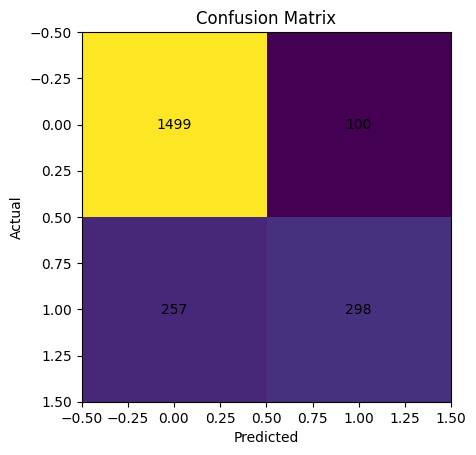

In [13]:
# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Adding numbers inside matrix
for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.show()

In [14]:
# MODEL COEFFICIENTS
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Weight': model.coef_[0]
})

print("\nModel Coefficients:\n")
print(coefficients)

print("\nBias (Intercept):", model.intercept_[0])


Model Coefficients:

                                              Feature    Weight
0                            indoor_co2_concentration  0.882747
1                        indoor_operative_temperature  0.246620
2                            indoor_relative_humidity  0.065744
3           current_value_minus_average_last_hour_co2  0.759852
4   current_value_minus_average_last_hour_operativ...  0.158488
5   current_value_minus_average_last_hour_relative... -0.111774
6                               average_co2_last_hour  0.698233
7             average_operative_temperature_last_hour  0.207201
8                 average_relative_humidity_last_hour  0.090582
9                 current_value_minus_last_15_min_co2 -0.074852
10  current_value_minus_last_15_min_operative_temp...  0.061471
11  current_value_minus_last_15_min_relative_humidity  0.080358
12                                        room_number -3.472269
13                                            kitchen -0.419198
14                